# Clasificacion de Datos

Lucho Mar| 2024 <br>
Tout Doucement by Feist

Clasifiqué imágenes del conjunto de datos CIFAR‑10 utilizando una Red Neuronal Convolucional personalizada construida con TensorFlow/Keras.

- Preprocesamiento del conjunto de datos CIFAR-10
- Modelo CNN con BatchNorm y Dropout
- Programación de la tasa de aprendizaje + detención temprana (Early stopping)
- Gráficos de precisión + matriz de confusión
- Notebook de Jupyter limpio y reproducible

## Import Packages

In [1]:
import os
import urllib.request

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from keras import regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.datasets import cifar10
from keras.layers import (BatchNormalization, Conv2D, Dense, Dropout, Flatten,
                          MaxPool2D, MaxPooling2D)
from keras.models import Sequential
from keras.optimizers import Adam
from keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Import dataset & Processing

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train, test_size=0.1, random_state=101)

In [4]:
X_train.shape, y_train.shape

((45000, 32, 32, 3), (45000, 1))

In [5]:
X_valid.shape, y_valid.shape

((5000, 32, 32, 3), (5000, 1))

In [6]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [7]:
class_names = ['airplane', 'automobile', 'bird','cat','deer','dog','frog','horse','ship','truck']

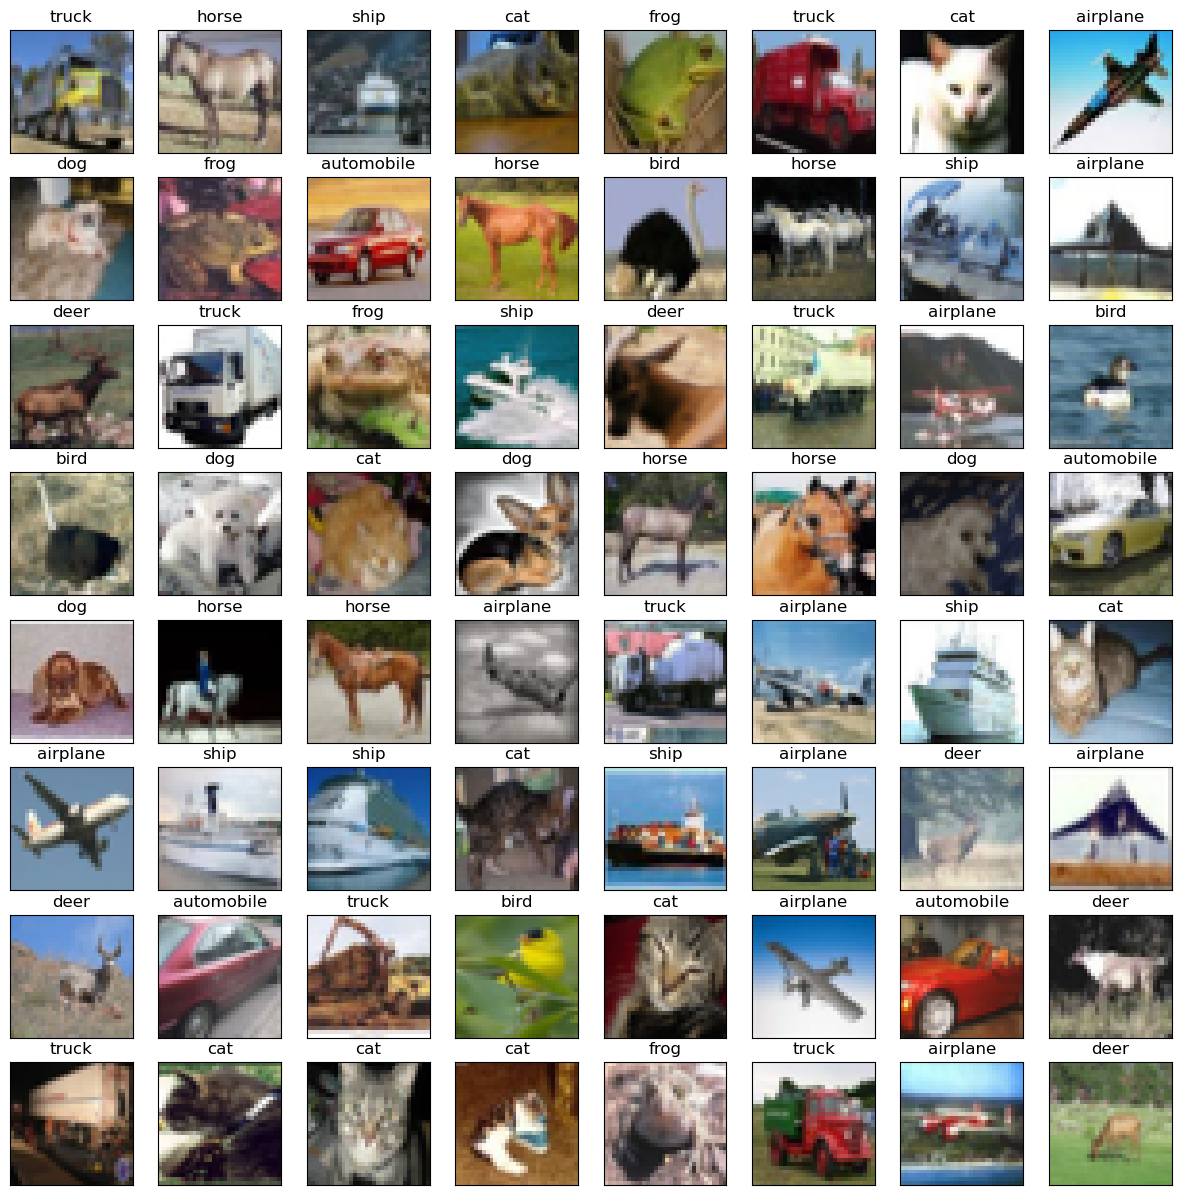

In [8]:
plt.figure(figsize=(15,15))
for i in range(64):
  plt.subplot(8,8,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])

plt.show()
     


### Procesamiento de datos
    - Normalización de imágenes
    - Codificación one-hot de etiquetas
    - Aumento de datos (Data Augmentation)

#### Normalizacion

In [9]:
# Convertir los valores de píxeles a tipo float32

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_valid = X_valid.astype('float32')

# Calcular la media y la desviación estándar de las imágenes de entrenamiento
mean = np.mean(X_train)
std = np.std(X_train)

# Normalizar los datos
X_train = (X_train - mean) / (std + 0.00000001)
X_test = (X_test - mean) / (std + 0.00000001)
X_valid = (X_valid - mean) / (std + 0.00000001)


#### Onehot encoder

In [10]:
y_train = to_categorical(y_train,10)
y_valid = to_categorical(y_valid,10)
y_test = to_categorical(y_test,10)

#### Aumento de datos 

In [11]:
data_generator = ImageDataGenerator(
    rotation_range = 15,  # Rotar imágenes hasta 15 grados
    width_shift_range = 0.12,  # Desplazar imágenes horizontalmente hasta un 12% del ancho
    height_shift_range = 0.12,  # Desplazar imágenes verticalmente hasta un 12% de la altura
    horizontal_flip = True,  # Voltear imágenes horizontalmente
    zoom_range = 0.1,  # Aplicar zoom aleatorio hasta un 10%
    brightness_range = [0.9, 1.1],  # Variar el brillo entre 90% y 110%
    shear_range = 10,  # Intensidad de cizalladura (ángulo en sentido antihorario)
    channel_shift_range = 0.1  # Desplazamiento de los canales de color
)

### Modelo

In [12]:
model = Sequential()

weight_decay = 0.0001  # Decaimiento del peso para la regularización L2

# Primera capa convolucional
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay), input_shape=X_train.shape[1:]))
model.add(BatchNormalization())

# Segunda capa convolucional
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Agregar la primera capa de max pooling con tamaño de 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))
# Agregar capa Dropout con tasa de 0.2
model.add(Dropout(rate=0.2))


# Agregar la tercera y cuarta capa convolucional
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Agregar la segunda capa de max pooling con tamaño de 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))
# Agregar capa Dropout con tasa de 0.3
model.add(Dropout(rate=0.3))


# Quinta y sexta capa convolucional
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Agregar la tercera capa de max pooling con tamaño de 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))
# Agregar capa Dropout con tasa de 0.4
model.add(Dropout(rate=0.4))


# Séptima y octava capa convolucional
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu', 
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Agregar la cuarta capa de max pooling con tamaño de 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))
# Agregar capa Dropout con tasa de 0.5
model.add(Dropout(rate=0.5))


# Aplanar la salida del tensor desde la capa anterior
model.add(Flatten())

# Agregar una capa completamente conectada con función de activación softmax
model.add(Dense(10, activation='softmax'))


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,186,346 (4.53 MB)

 Trainable params: 1,184,426 (4.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [14]:
# Establecer el tamaño del lote (batch size)
batch_size = 64

# Número de épocas (podrías usar 300 o 400 en lugar de 150)
epochs = 50

# Definir el optimizador Adam con una tasa de aprendizaje específica
optimizer = Adam(learning_rate=0.0005)

# Compilar el modelo con función de pérdida y métrica de precisión
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Reducir la tasa de aprendizaje si la pérdida de validación no mejora
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

# Detener el entrenamiento temprano si no hay mejora en la pérdida de validación
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

# Entrenar el modelo utilizando los datos aumentados
model.fit(data_generator.flow(X_train, y_train, batch_size=batch_size),
          epochs=epochs,
          validation_data=(X_valid, y_valid),
          callbacks=[reduce_lr, early_stopping],
          verbose=2)


Epoch 1/50


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


704/704 - 136s - 193ms/step - accuracy: 0.3364 - loss: 2.3345 - val_accuracy: 0.4332 - val_loss: 1.7885 - learning_rate: 5.0000e-04
Epoch 2/50
704/704 - 116s - 165ms/step - accuracy: 0.4640 - loss: 1.7413 - val_accuracy: 0.5126 - val_loss: 1.9245 - learning_rate: 5.0000e-04
Epoch 3/50
704/704 - 116s - 165ms/step - accuracy: 0.5303 - loss: 1.5139 - val_accuracy: 0.5992 - val_loss: 1.2840 - learning_rate: 5.0000e-04
Epoch 4/50
704/704 - 117s - 166ms/step - accuracy: 0.5731 - loss: 1.3705 - val_accuracy: 0.6298 - val_loss: 1.3806 - learning_rate: 5.0000e-04
Epoch 5/50
704/704 - 115s - 164ms/step - accuracy: 0.6064 - loss: 1.2641 - val_accuracy: 0.6324 - val_loss: 1.3514 - learning_rate: 5.0000e-04
Epoch 6/50
704/704 - 120s - 170ms/step - accuracy: 0.6311 - loss: 1.1781 - val_accuracy: 0.6808 - val_loss: 1.0337 - learning_rate: 5.0000e-04
Epoch 7/50
704/704 - 121s - 171ms/step - accuracy: 0.6603 - loss: 1.0846 - val_accuracy: 0.6842 - val_loss: 1.0292 - learning_rate: 5.0000e-04
Epoch 8/50

### Visualizacion del modelo

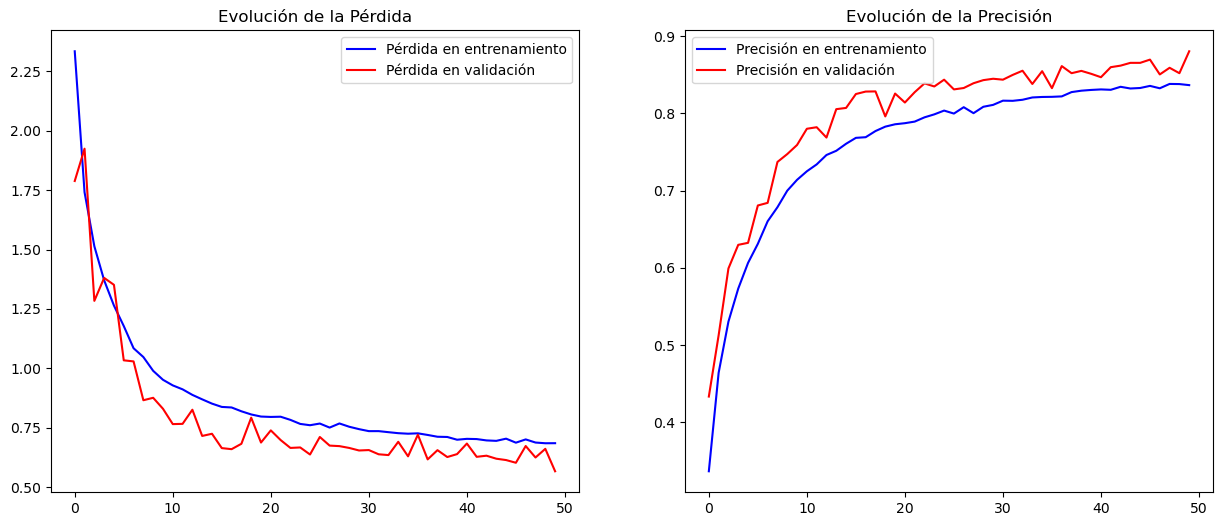

In [15]:
plt.figure(figsize=(15,6))

# Gráfico de la evolución de la pérdida
plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label='Pérdida en entrenamiento', color='blue')
plt.plot(model.history.history['val_loss'], label='Pérdida en validación', color='red')
plt.legend()
plt.title('Evolución de la Pérdida')

# Gráfico de la evolución de la precisión
plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label='Precisión en entrenamiento', color='blue')
plt.plot(model.history.history['val_accuracy'], label='Precisión en validación', color='red')
plt.legend()
plt.title('Evolución de la Precisión')

plt.show()

### Evaluacion del Modelo & Testeo Data

In [16]:
# Evaluar el modelo con los datos de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

# Imprimir los resultados
print(f'Precisión en el conjunto de prueba: {test_acc}\nPérdida en el conjunto de prueba: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8651 - loss: 0.6139
Precisión en el conjunto de prueba: 0.8651000261306763
Pérdida en el conjunto de prueba: 0.6138983964920044


In [17]:
print(f'Precisión en el conjunto de prueba: {test_acc*100:.2f}%')


Precisión en el conjunto de prueba: 86.51%


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


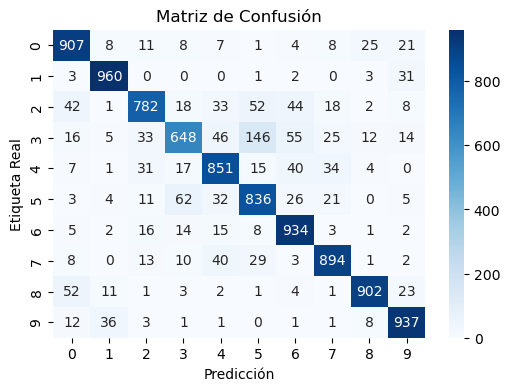

In [18]:
# Obtener las predicciones del modelo 
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Obtener las etiquetas reales 
y_true = np.argmax(y_test, axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Mostrar la matriz de confusión con un mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

### Desempeño en una imagen fuera del conjunto de datos

In [19]:
url = 'https://naturealberta.ca/wp-content/uploads/2025/04/6.-Tree-Swallow-NICK-CARTER-1536x1340.jpg'
#'https://wildjolie.com/cdn/shop/articles/Do_Horses_Have_Horns.jpg?v=1741247407&width=1780'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

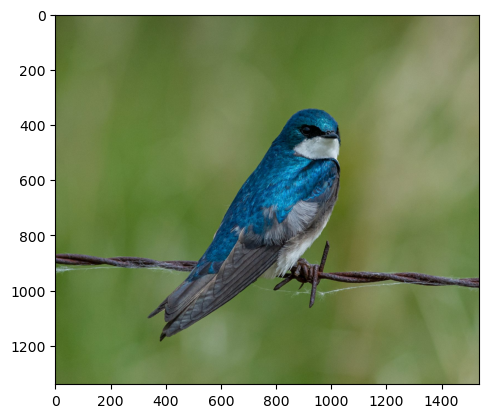

In [20]:
plt.imshow(image)
plt.show()

In [21]:
image.shape

(1340, 1536, 3)

In [22]:
image = cv2.resize(image, (32, 32))

# Normalizar la imagen
image = (image - mean) / (std + 0.000001)

# Agregar una dimensión extra porque el modelo espera un lote (batch) de imágenes
image = image.reshape((1, 32, 32, 3))

In [23]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [24]:
predict

array([[1.5194218e-01, 1.3801092e-04, 8.0995142e-01, 7.6763271e-03,
        2.9211008e-04, 2.3264194e-02, 3.3057942e-03, 2.3536058e-03,
        5.6071702e-04, 5.1557814e-04]], dtype=float32)

In [25]:
print(f'La clase predicha: {class_names[predict.argmax()]}')

La clase predicha: bird
